In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

#Pre-processing
data = pd.read_csv("FraudShield_Banking_Data.csv")
data_new = data.drop(columns=['Customer_ID', 'Merchant_ID', 'Device_ID', ])
data_new.dropna(inplace=True)
data_new['Unusual_Time_Transaction'] = data_new['Unusual_Time_Transaction'].map({'Yes': 1, 'No': 0}, na_action='ignore')
data_new['Is_New_Merchant'] = data_new['Is_New_Merchant'].map({'Yes': 1, 'No': 0}, na_action='ignore')
data_new['Is_International_Transaction'] = data_new['Is_International_Transaction'].map({'Yes': 1, 'No': 0}, na_action='ignore')
data_new['Fraud_Label'] = data_new['Fraud_Label'].map({'Fraud': 1, 'Normal': 0}, na_action='ignore')
data_new = data_new.rename(columns={'Fraud_Label': 'Is_Fraud'})

In [78]:


# Choose features
features = data_new[['Daily_Transaction_Count', 'Weekly_Transaction_Count']]
target = data_new['Is_Fraud']

# Package into a Bunch
fraud_data = Bunch(
    data=features.values,
    target=target.values,
    feature_names=features.columns.tolist(),
    target_names=["Legitimate", "Fraudulent"],
)

X = pd.DataFrame(fraud_data.data, columns=fraud_data.feature_names)
y = pd.Series(fraud_data.target, name="target")

target_names = fraud_data.target_names

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (39900, 2)
Test set shape: (9976, 2)


In [79]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results = {
        "model": model_name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    }

    if hasattr(model, "predict_proba"):
        test_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, test_proba)
        roc_auc = auc(fpr, tpr)
        results["roc_auc"] = roc_auc
    else:
        results["roc_auc"] = np.nan

    return model, results


def plot_confusion(cm, title):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Fraudulent", "Legitimate"])
    ax.set_yticklabels(["Fraudulent", "Legitimate"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.show()


def plot_roc_curves(curves_dict):
    fig, ax = plt.subplots()
    for name, (fpr, tpr, roc_auc) in curves_dict.items():
        ax.plot(fpr, tpr, label=f"{name}  AUC={roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curves on the test set")
    ax.legend()
    plt.show()


def plot_decision_boundary(model, X, y, title, feature_names):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots()
    ax.contourf(xx, yy, Z, alpha=0.25)

    for cls, label in zip([0, 1], ["malignant", "benign"]):
        mask = y == cls
        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            label=label,
            alpha=0.8
        )

    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    ax.legend()
    plt.show()

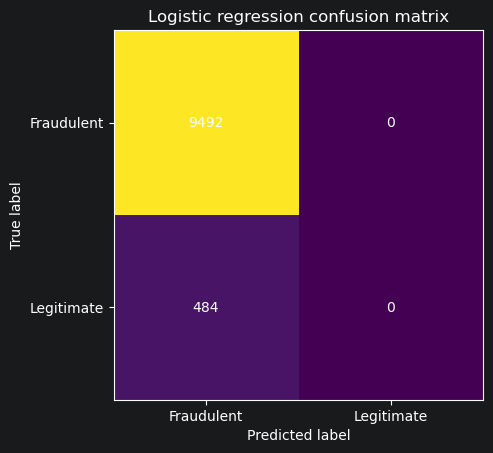

              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.98      9492
  Fraudulent       0.00      0.00      0.00       484

    accuracy                           0.95      9976
   macro avg       0.48      0.50      0.49      9976
weighted avg       0.91      0.95      0.93      9976



/opt/anaconda3/envs/ds2010-finalproject-1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ds2010-finalproject-1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ds2010-finalproject-1/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [82]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

log_reg, logreg_results = evaluate_classifier(
    log_reg, X_train, X_test, y_train, y_test, "Logistic Regression"
)
pd.DataFrame([logreg_results])

logreg_test_pred = log_reg.predict(X_test)
logreg_cm = confusion_matrix(y_test, logreg_test_pred)
plot_confusion(logreg_cm, "Logistic regression confusion matrix")

print(classification_report(y_test, logreg_test_pred, target_names=target_names))